Ejemplo de aplicación de "Logistic regression":
Modelo de juguete de una transición de fase

x = (m, e, chi)  -->  y = 0/1 según T < Tc o T > Tc

Objetivo didáctico: ver cómo, a partir de observables físicos ruidosos, un clasificador simple aprende el régimen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

Generador de dataset toy

In [2]:
def make_phase_transition_toy(
    n=2000,
    Tc=2.269,              # Tc del Ising 2D (solo como referencia)
    T_min=1.0,
    T_max=4.0,
    noise=0.18,
    seed=0
):
    rng = np.random.default_rng(seed)

    # Temperaturas (una por muestra)
    T = rng.uniform(T_min, T_max, size=n)

    # Etiqueta (régimen): 0 ordenado (T<Tc), 1 desordenado (T>Tc)
    y = (T > Tc).astype(int)

    # --- Observables toy (NO son fórmulas exactas; están "inspiradas" en el comportamiento cualitativo) ---
    # Magnetización media: ~ (1 - T/Tc)^beta para T<Tc, ~0 para T>Tc
    beta = 0.125
    m_clean = np.zeros(n)              # todo a 0 (valor para T >= Tc)
    mask = T < Tc
    m_clean[mask] = (1.0 - (T[mask] / Tc)) ** beta  # sobreescribe solo T < Tc

    # Energía por espín: suave, más negativa a baja T, tiende a 0 a alta T (toy)
    e_clean = -np.tanh(1.2 / T)  # solo para dar una curva monotónica razonable

    # Susceptibilidad: pico cerca de Tc (toy Lorentziana)
    gamma = 1.0
    width = 0.18
    chi_clean = 0.2 + gamma / (1.0 + ((T - Tc) / width) ** 2)

    # Ruido experimental/simulacional
    m = m_clean + rng.normal(0, noise, size=n)
    e = e_clean + rng.normal(0, noise, size=n)
    chi = chi_clean + rng.normal(0, 0.25 * noise, size=n)

    # (Opcional) truncar rangos para que tenga sentido físico
    m = np.clip(m, 0, 1)           # magnetización entre 0 y 1
    chi = np.clip(chi, 0, None)    # susceptibilidad positiva

    X = np.column_stack([m, e, chi])
    return X, y, T

X, y, T = make_phase_transition_toy(n=2500, seed=42)

Pintamos observables vs T (para ver el "cambio de régimen" cualitativo)

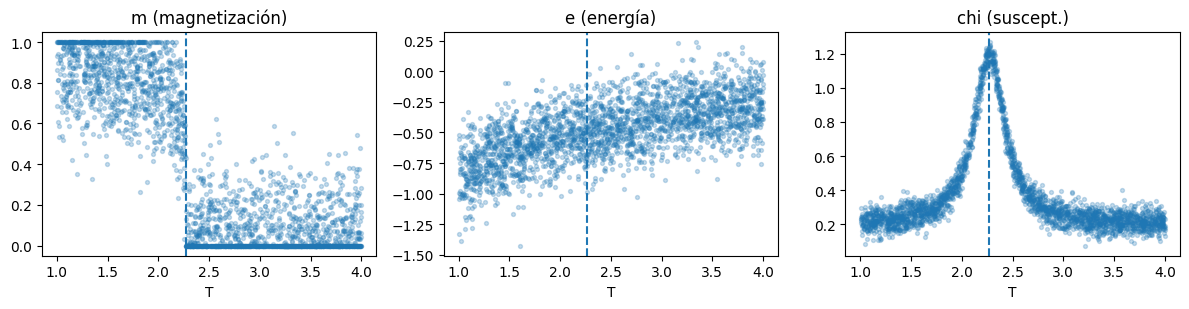

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
names = ["m (magnetización)", "e (energía)", "chi (suscept.)"]
for j in range(3):
    ax[j].scatter(T, X[:, j], s=8, alpha=0.25)
    ax[j].axvline(2.269, linestyle="--")  # Tc de referencia (si coincide con el usado)
    ax[j].set_xlabel("T")
    ax[j].set_title(names[j])
plt.tight_layout()

Pipeline: escalado + LR

In [4]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

Split train/test + fit

In [5]:
X_train, X_test, y_train, y_test, T_train, T_test = train_test_split(
    X, y, T, test_size=0.25, random_state=0, stratify=y
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]  # probabilidad de clase "desordenado" (1)

print("=== Report (test) ===")
print(classification_report(y_test, y_pred, target_names=["ordenado (0)", "desordenado (1)"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC (test):", roc_auc_score(y_test, y_proba))


=== Report (test) ===
                 precision    recall  f1-score   support

   ordenado (0)       0.98      0.98      0.98       266
desordenado (1)       0.98      0.99      0.99       359

       accuracy                           0.98       625
      macro avg       0.98      0.98      0.98       625
   weighted avg       0.98      0.98      0.98       625

Confusion matrix:
 [[260   6]
 [  4 355]]
ROC AUC (test): 0.9987014890987915


Notad que de la matriz de confusión obtenemos la siguiente información:

* Predichos como 0 = 260 + 4 = 264
* Correctos como 0 = 260
* Predichos como 1 = 6 + 355 = 361
* Correctos como 1 = 355

"Termómetro" del modelo: P(desordenado | x) vs T
Si el clasificador está bien, esta probabilidad crece con T y cruza ~0.5 cerca de Tc.

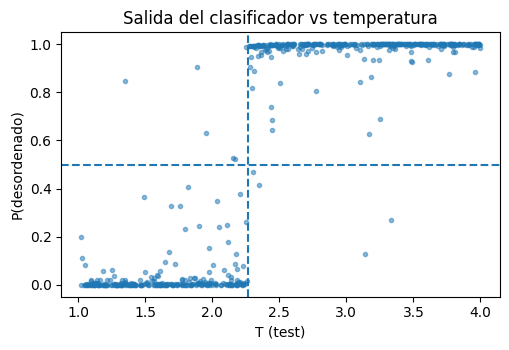

In [6]:
order = np.argsort(T_test)
plt.figure(figsize=(5.2, 3.6))
plt.plot(T_test[order], y_proba[order], marker=".", linestyle="None", alpha=0.5)
plt.axhline(0.5, linestyle="--")
plt.axvline(2.269, linestyle="--")
plt.xlabel("T (test)")
plt.ylabel("P(desordenado)")
plt.title("Salida del clasificador vs temperatura")
plt.tight_layout()

plt.show()

Comprobación adicional: "No me fío de una sola partición: quiero ver si el resultado es estable.”

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
print("\n=== CV (5-fold) AUC ===")
print("AUC por fold:", np.round(auc_scores, 3))
print(f"AUC = {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")


=== CV (5-fold) AUC ===
AUC por fold: [0.999 0.999 0.999 1.    0.999]
AUC = 0.999 ± 0.000
